# Installing Required Libraries

In [1]:
!pip install tensorflow keras

# Loading Required Libraries

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

## Loading and Split the data into x_train, y_train, x_test and y_test.

In [4]:
from tensorflow.keras.datasets import mnist

In [5]:
#spliting the dataset into Train Test set
(x_train,y_train),(x_test,y_test)  = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Displaying the sample images from x_train

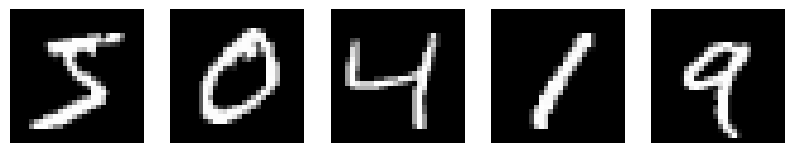

In [6]:
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
plt.show()


## Display the shape of x_train and y_train

In [7]:
# Display the shape of x_train and y_train
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)


# Displaying The Dataset

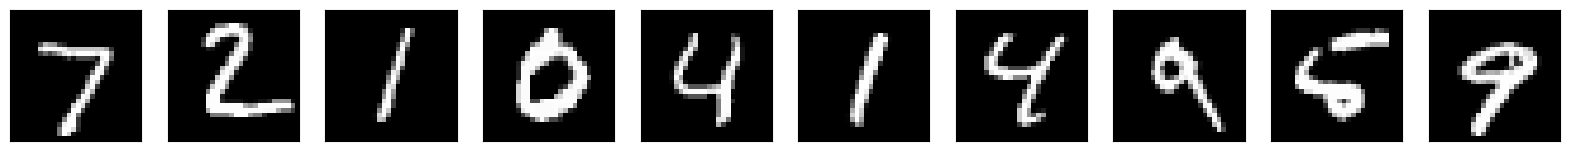

In [8]:
#number of images to be display
n=10
#plot figure size
plt.figure(figsize=(20,4))
#loop for each image displaying

for i in range(n):
    ax= plt.subplot(2, n, i+1) #subplot (a smaller section of the figure) where the image will be displayed.
    plt.imshow(x_test[i].reshape(28,28))

    #set color black and white
    plt.gray()

    #hiding x and y labels

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

plt.close()

# Flattening the Images

In [9]:
#  Reshape the images from 28x28 to 784-dimension vector.

x_train= x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

In [10]:
# After Flattening now the shape of dataset is

x_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

# Data Scaling
1. Convert the data into float 32 type
2. Scale the data by dividing x_train and y_train by 255

In [11]:
x_train = x_train.astype("float32")/255.0
x_test = x_test.astype('float32')/255.0

3. Displaying the shape of x_train after scaling

In [12]:
print("x_train shape (after scaling):", x_train.shape)
print("y_train shape (after scaling):", y_train.shape)

x_train shape (after scaling): (60000, 784)
y_train shape (after scaling): (60000,)


# One Hot Encoding

In [13]:
num_classes= 10

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print("New Y_train shape {},\nNew y_test shape{}".format(y_train.shape, y_test.shape))

New Y_train shape (60000, 10),
New y_test shape(10000, 10)


# Hyper parameters for the neural networks

In [14]:
# Learning rate
learning_rate = 0.001

# the number of complete passes through the dataset during training
num_epochs = 30

# the number of data samples to process in each batch
batch_size = 128

# the input size for each data sample
input_size = 784

# number of neurons in the first hidden layer
hidden_layer1 = 256

# number of neurons in the Second hidden layer
hidden_layer2 = 128

# number of neurons in the Third hidden layer
hidden_layer3= 128

# number of neurons in the fourth hidden layer
hidden_layer4= 64

# the total number of classes/categories in the dataset
num_classes = 10       # 10 classes in MNIST dataset

# Building Model

In [15]:
#building model

model= Sequential()
# hidden layer 1
model.add(Dense(hidden_layer1, input_dim = input_size, activation= 'relu'))
# 2nd layer
model.add(Dense(hidden_layer2, activation= 'relu'))
#3rd layer
model.add(Dense(hidden_layer3, activation= 'relu'))
#4th layer
model.add(Dense(hidden_layer4, activation= 'relu'))

# softmax for multiclass classification
model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Model Compile

In [16]:
model.compile(loss="categorical_crossentropy", metrics=["accuracy"], optimizer= 'adam')

# Model Summary

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 259,274 (1012.79 KB)

 Trainable params: 259,274 (1012.79 KB)

 Non-trainable params: 0 (0.00 B)

# Training the Neural Network

In [18]:
history = model.fit(x_train, y_train, epochs=num_epochs, batch_size=batch_size, verbose= 1)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8421 - loss: 0.5292
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9675 - loss: 0.1096
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9782 - loss: 0.0683
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9831 - loss: 0.0530
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9884 - loss: 0.0375
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9902 - loss: 0.0303
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9913 - loss: 0.0270
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9929 - loss: 0.0217
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9928 - loss: 0.0206
Epoch 10/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9945 - loss: 0.0161
Epoch 11/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9947 - loss: 0.0150
Epoch 12/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/

# Testing The Model

In [19]:
# accuracy of the model
y_pred_prob= model.predict(x_test, verbose=0)
y_pred= np.where(y_pred_prob >0.5, 1, 0)

test_accuracy= round(accuracy_score(y_pred,y_test)*100,2)

In [20]:
# Compare training and testing accuracy
train_accuracy = round(history.history['accuracy'][-1]*100,2)  # Get the last epoch's training accuracy
print(f"Training accuracy: {train_accuracy}% , Testing accuracy: {test_accuracy}%")

Training accuracy: 99.79% , Testing accuracy: 98.11%


# Displaying the predicted labels along the input image.

In [21]:
# Define a mask for selecting a range of indices (20 to 49)
mask = range(5, 30)

# first 20 samples from the test set for visualization
X_valid = x_test[0:10]
actual_labels = y_test[0:5]

# Predict probabilities for the selected validation samples
y_pred_probs_valid = model.predict(X_valid)
y_pred_valid = np.where(y_pred_probs_valid > 0.5, 1, 0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [22]:
label_mapping = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9"
}


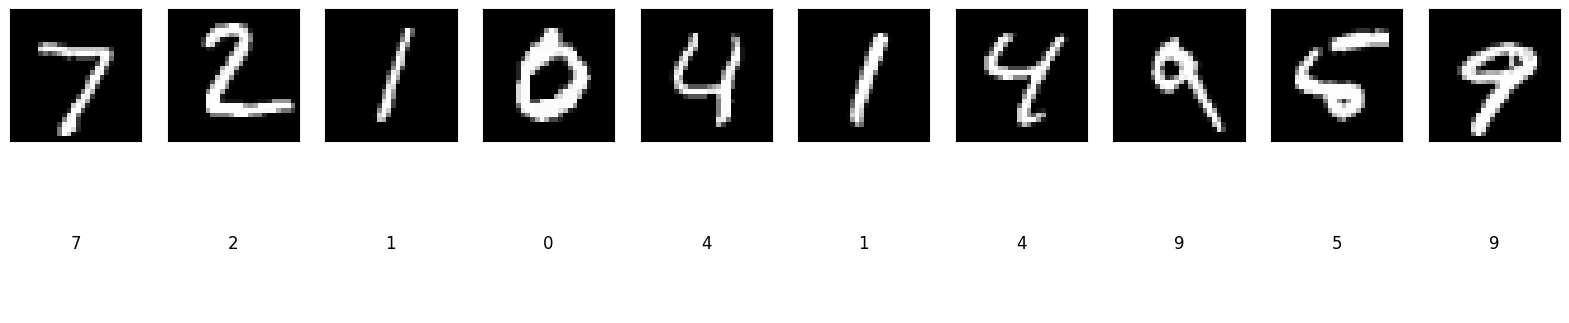

In [23]:
# Set up a figure to display images
n = len(X_valid)
plt.figure(figsize=(20, 4))

for i in range(n):
    # Display the original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_valid[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display the predicted label
    predicted_digit = np.argmax(y_pred_probs_valid[i])
    predicted_label = label_mapping[predicted_digit]
    ax = plt.subplot(2, n, i + 1 + n)
    plt.text(0.5, 0.5, predicted_label, fontsize=12, ha='center', va='center')
    plt.axis('off')

# Show the plotted images
plt.show()

# Close the plot
plt.close()